In [13]:
# imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import heapq
import itertools
from typing import Callable
import time

np.random.seed(1234)

stations = ["G", "L", "B", "Z"]
station_to_idx = {s: i for i, s in enumerate(stations)}

# Demand rates during peak periods [1000 passengers/h]
demand_peak = np.array(
    [
        [np.nan, 1.5, 2.2, 1.3],
        [np.nan, np.nan, 2.4, 1.1],
        [np.nan, np.nan, np.nan, 3.3],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Demand rates during off-peak periods [1000 passengers/h]
demand_offpeak = np.array(
    [
        [np.nan, 0.4, 0.3, 0.5],
        [np.nan, np.nan, 0.5, 0.3],
        [np.nan, np.nan, np.nan, 0.5],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Proportion of first class passengers during peak periods
first_class_ratio_peak = np.array(
    [
        [np.nan, 0.13, 0.15, 0.17],
        [np.nan, np.nan, 0.21, 0.18],
        [np.nan, np.nan, np.nan, 0.32],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Proportion of first class passengers during off-peak periods
first_class_ratio_offpeak = np.array(
    [
        [np.nan, 0.21, 0.18, 0.23],
        [np.nan, np.nan, 0.24, 0.23],
        [np.nan, np.nan, np.nan, 0.19],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

df_demand_peak = pd.DataFrame(demand_peak, index=stations, columns=stations)
df_demand_offpeak = pd.DataFrame(demand_offpeak, index=stations, columns=stations)
df_first_class_ratio_peak = pd.DataFrame(
    first_class_ratio_peak, index=stations, columns=stations
)
df_first_class_ratio_offpeak = pd.DataFrame(
    first_class_ratio_offpeak, index=stations, columns=stations
)

In [14]:
def exponential_rng(lam: float, u: float):
    """Generates exponential random number."""
    if lam <= 0:
        return float("inf")

    u = min(max(float(u), np.finfo(float).tiny), 1.0 - np.finfo(float).eps)
    return -np.log(u) / lam


# Price and cost constants
PRICE_FIRST = 40
PRICE_SECOND = 20
MISSED_COST_FIRST = 30
MISSED_COST_SECOND = 10
EMPTY_COST_FIRST = 20
EMPTY_COST_SECOND = 10

# Fixed passenger demand peak periods.
PASSENGER_PEAK_TIMES = (
    (420, 540),    # 7:00 - 9:00
    (960, 1080),   # 16:00 - 18:00
)

SIMULATION_START = 0.0
SIMULATION_END = 24 * 60.0

# Operational constraint: headway between consecutive trains < 1 hour.
MIN_HEADWAY = 1.0
MAX_HEADWAY = 59.0

# Maximum train length: 150 m / 25 m per carriage = 6 carriages.
max_number_of_carriages = 6


def get_travel_time(station):
    """Returns the travel time to the next station in minutes."""
    if station == "G":
        return 40
    if station == "L":
        return 70
    if station == "B":
        return 60
    return 0


def get_num_stations(origin, destination):
    return station_to_idx[destination] - station_to_idx[origin]


def t_in_intervals(t, intervals):
    """Checks if time t is within any of the given intervals."""
    if intervals is None:
        return False

    time_of_day = t % (24 * 60)
    return any(start <= time_of_day < end for start, end in intervals)


def is_peak(time_minutes, peak_times=PASSENGER_PEAK_TIMES):
    """Checks if time is within the specified peak intervals."""
    return t_in_intervals(time_minutes, peak_times)


def is_passenger_peak(time_minutes):
    """
    Passenger peak periods are fixed input data.
    These are not decision variables.
    """
    return is_peak(time_minutes, PASSENGER_PEAK_TIMES)


def passenger_periods_for_day():
    """Returns exact demand-rate intervals over the 24-hour simulation horizon."""
    periods = []
    current = SIMULATION_START

    for start, end in PASSENGER_PEAK_TIMES:
        if current < start:
            periods.append((current, float(start), False))

        periods.append((float(start), float(end), True))
        current = float(end)

    if current < SIMULATION_END:
        periods.append((current, SIMULATION_END, False))

    return periods

In [15]:
class UniformStream:
    """
    Deterministic stream of U(0,1) numbers.

    The simulation receives a vector u.
    Each time a random number is needed, stream.rand() consumes the next value.
    """

    def __init__(self, u: np.ndarray | None = None, seed: int | None = None):
        self.u = np.asarray([] if u is None else u, dtype=float)
        self.index = 0
        self.rng = np.random.default_rng(seed)

    def rand(self):
        if self.index < len(self.u):
            value = self.u[self.index]
        else:
            value = self.rng.random()

        self.index += 1
        return min(max(float(value), np.finfo(float).tiny), 1.0 - np.finfo(float).eps)

In [16]:
class Passenger:
    def __init__(self, arrival_time, origin, destination, is_first_class):
        self.arrival_time = arrival_time
        self.origin = origin
        self.destination = destination
        self.is_first_class = is_first_class
        self.missed_trains = 0


@dataclass(frozen=True)
class TrainType:
    """Train can have a maximum number of six carriages."""

    name: str
    first_class_carriages: int
    second_class_carriages: int

    def __repr__(self):
        return (
            f"{self.name}"
            f"({self.first_class_carriages}F,"
            f"{self.second_class_carriages}S)"
        )

    def __post_init__(self):
        total_carriages = self.first_class_carriages + self.second_class_carriages

        if total_carriages > max_number_of_carriages:
            raise ValueError(
                f"Total carriages cannot exceed {max_number_of_carriages}."
            )

        if total_carriages <= 0:
            raise ValueError("A train must have at least one carriage.")

        if self.first_class_carriages < 0 or self.second_class_carriages < 0:
            raise ValueError("Carriage numbers cannot be negative.")


@dataclass
class Train:
    train_id: int
    train_type: TrainType

    onboard_first: list = None
    onboard_second: list = None

    def __post_init__(self):
        self.onboard_first = []
        self.onboard_second = []

    @property
    def capacity_first(self):
        return self.train_type.first_class_carriages * 300

    @property
    def capacity_second(self):
        return self.train_type.second_class_carriages * 500


@dataclass
class Event:
    """Generic event."""

    time: float


class PassengerGeneration(Event):
    """A passenger arrives at the station."""

    def __init__(self, time, origin, destination, is_first_class):
        super().__init__(time)
        self.origin = origin
        self.destination = destination
        self.is_first_class = is_first_class


@dataclass
class TrainArrival(Event):
    """The train arrives at a station."""

    station: str
    train: Train
    

base_train = TrainType(name="base", first_class_carriages=1, second_class_carriages=3)
short_train = TrainType(name="short", first_class_carriages=1, second_class_carriages=1)
long_train = TrainType(name="long", first_class_carriages=1, second_class_carriages=5)

In [17]:
from dataclasses import dataclass


@dataclass
class Event:
    """Generic event."""

    time: float


class PassengerGeneration(Event):
    """A passenger arrives at the station"""

    def __init__(self, time, origin, destination, is_first_class):
        super().__init__(time)
        self.origin = origin
        self.destination = destination
        self.is_first_class = is_first_class


@dataclass
class TrainArrival(Event):
    """The train arrives at a station"""

    station: str
    train: Train


In [18]:
def get_arrival_rate(origin, destination, time):
    """Arrival rate in passengers per minute for a route."""
    i = station_to_idx[origin]
    j = station_to_idx[destination]

    demand = demand_peak if is_passenger_peak(time) else demand_offpeak
    total_demand_per_hour = demand[i, j] * 1000

    if np.isnan(total_demand_per_hour):
        return 0.0

    return total_demand_per_hour / 60.0


def get_arrival_rate_by_period(origin, destination, peak: bool):
    """Arrival rate in passengers per minute for an exact peak/off-peak period."""
    i = station_to_idx[origin]
    j = station_to_idx[destination]

    demand = demand_peak if peak else demand_offpeak
    total_demand_per_hour = demand[i, j] * 1000

    if np.isnan(total_demand_per_hour):
        return 0.0

    return total_demand_per_hour / 60.0


def draw_passenger_class(origin, destination, time, stream: UniformStream):
    """
    Returns True for first class, False for second class.
    """
    i = station_to_idx[origin]
    j = station_to_idx[destination]

    if is_passenger_peak(time):
        first_ratio = first_class_ratio_peak[i, j]
    else:
        first_ratio = first_class_ratio_offpeak[i, j]

    return stream.rand() < first_ratio


def generate_timetable(
    freq_peak,
    freq_offpeak,
    train_type=base_train,
    train_peak_times=PASSENGER_PEAK_TIMES,
):
    scenario = Scenario(
        train_frequency_peak=freq_peak,
        train_frequency_offpeak=freq_offpeak,
        train_config_1=train_type,
        train_config_2=train_type,
        peak_times=train_peak_times,
    )

    return scenario.get_timetable(sorted_by_time=True)

In [19]:
from dataclasses import dataclass





def t_in_intervals(t, intervals: list[tuple[float]] | None):
    """Checks if time t is within any of the given intervals"""
    return any(start <= t <= end for start, end in intervals or [])


@dataclass(frozen=True)
class Scenario:
    """
    Scenario decision variables.

    Interpretation:
    - train_frequency_peak: headway used during train-service peak intervals.
    - train_frequency_offpeak: headway used outside train-service peak intervals.
    - train_config_1: peak train composition.
    - train_config_2: off-peak train composition.
    - peak_times: train-service peak intervals, not passenger demand intervals.
    """

    train_frequency_peak: float
    train_frequency_offpeak: float
    train_config_1: TrainType
    train_config_2: TrainType | None = None
    train_config_3: TrainType | None = None
    train_type_2_intervals: tuple[tuple[float, float], ...] | None = None
    train_type_3_intervals: tuple[tuple[float, float], ...] | None = None
    peak_times: tuple[tuple[float, float], ...] = PASSENGER_PEAK_TIMES

    def __post_init__(self):
        if not (MIN_HEADWAY <= self.train_frequency_peak <= MAX_HEADWAY):
            raise ValueError(
                f"Peak headway must be in "
                f"[{MIN_HEADWAY}, {MAX_HEADWAY}] minutes."
            )

        if not (MIN_HEADWAY <= self.train_frequency_offpeak <= MAX_HEADWAY):
            raise ValueError(
                f"Off-peak headway must be in "
                f"[{MIN_HEADWAY}, {MAX_HEADWAY}] minutes."
            )

        object.__setattr__(
            self,
            "peak_times",
            tuple(tuple(x) for x in self.peak_times),
        )

        if self.train_type_2_intervals is not None:
            object.__setattr__(
                self,
                "train_type_2_intervals",
                tuple(tuple(x) for x in self.train_type_2_intervals),
            )

        if self.train_type_3_intervals is not None:
            object.__setattr__(
                self,
                "train_type_3_intervals",
                tuple(tuple(x) for x in self.train_type_3_intervals),
            )

    def train_type_at_time(self, t):
        if self.train_config_3 is not None and t_in_intervals(
            t, self.train_type_3_intervals
        ):
            return self.train_config_3

        if self.train_config_2 is not None and t_in_intervals(
            t, self.train_type_2_intervals
        ):
            return self.train_config_2

        if is_peak(t, self.peak_times):
            return self.train_config_1

        return self.train_config_2 if self.train_config_2 is not None else self.train_config_1

    def get_timetable(self, sorted_by_time: bool = True) -> list[TrainArrival]:
        train_events = []
        t = -120.0
        train_id = 0

        while t < SIMULATION_END:
            train_type = self.train_type_at_time(t)

            train = Train(
                train_id=train_id,
                train_type=train_type,
            )

            current_time = t

            for station in stations:
                train_events.append(TrainArrival(current_time, station, train))
                current_time += get_travel_time(station)

            if is_peak(t, self.peak_times):
                t += self.train_frequency_peak
            else:
                t += self.train_frequency_offpeak

            train_id += 1

        if sorted_by_time:
            train_events.sort(key=lambda event: event.time)

        return train_events

    def __str__(self):
        return (
            f"Peak frequency: {self.train_frequency_peak} min, "
            f"Off-peak frequency: {self.train_frequency_offpeak} min, "
            f"Peak train: {self.train_config_1}, "
            f"Off-peak train: "
            f"{self.train_config_2 if self.train_config_2 else self.train_config_1}, "
            f"Train peak times: {self.peak_times}"
        )

    @classmethod
    def create(
        cls,
        peak_frequency: float,
        non_peak_frequency: float,
        train1_first_class_carriages: int,
        train1_second_class_carriages: int,
        train2_first_class_carriages: int | None = None,
        train2_second_class_carriages: int | None = None,
        first_pre_peak_time_in_minutes: float = 0,
        first_post_peak_time_in_minutes: float = 0,
        second_pre_peak_time_in_minutes: float = 0,
        second_post_peak_time_in_minutes: float = 0,
    ):
        train_config_1 = TrainType(
            name="train1_peak",
            first_class_carriages=train1_first_class_carriages,
            second_class_carriages=train1_second_class_carriages,
        )

        if train2_first_class_carriages is None:
            train2_first_class_carriages = train1_first_class_carriages

        if train2_second_class_carriages is None:
            train2_second_class_carriages = train1_second_class_carriages

        train_config_2 = TrainType(
            name="train2_offpeak",
            first_class_carriages=train2_first_class_carriages,
            second_class_carriages=train2_second_class_carriages,
        )

        peak_times = (
            (
                PASSENGER_PEAK_TIMES[0][0] - first_pre_peak_time_in_minutes,
                PASSENGER_PEAK_TIMES[0][1] + first_post_peak_time_in_minutes,
            ),
            (
                PASSENGER_PEAK_TIMES[1][0] - second_pre_peak_time_in_minutes,
                PASSENGER_PEAK_TIMES[1][1] + second_post_peak_time_in_minutes,
            ),
        )

        return cls(
            train_frequency_peak=peak_frequency,
            train_frequency_offpeak=non_peak_frequency,
            train_config_1=train_config_1,
            train_config_2=train_config_2,
            peak_times=peak_times,
        )

@dataclass
class SimulationResult:
    time_history: list[int]
    queue_history: list[int]
    waiting_times: list[float]
    total_revenue: float
    total_missed_cost: float
    total_empty_cost: float
    list_available_first: list[int]
    list_available_second: list[int]
    times_available_first: list[float]
    times_available_second: list[float]
    runtime_s: float
    unserved_first: int = 0
    unserved_second: int = 0

    @property
    def net_profit(self):
        return self.total_revenue - self.total_missed_cost - self.total_empty_cost

    @property
    def unserved_total(self):
        return self.unserved_first + self.unserved_second

    def print_summary(self):
        waiting = np.array(self.waiting_times, dtype=float)

        mean_wait = np.mean(waiting) if waiting.size else np.nan
        max_wait = np.max(waiting) if waiting.size else np.nan
        p95_wait = np.quantile(waiting, 0.95) if waiting.size else np.nan

        print(f"Passengers served: {len(self.waiting_times):,.0f}")
        print(f"Passengers unserved at 24h: {self.unserved_total:,.0f}")
        print(f"Average waiting time: {mean_wait:.2f} minutes")
        print(f"95th percentile waiting time: {p95_wait:.2f} minutes")
        print(f"Max waiting time: {max_wait:.2f} minutes")
        print(f"Total revenue: {self.total_revenue:,.2f} CHF")
        print(f"Missed passenger costs: {self.total_missed_cost:,.2f} CHF")
        print(f"Empty seat costs: {self.total_empty_cost:,.2f} CHF")
        print(f"NET PROFIT: {self.net_profit:,.2f} CHF")
        print(f"Runtime: {self.runtime_s:.2f} seconds")

    def get_statistics(self):
        waiting = np.array(self.waiting_times, dtype=float)

        if waiting.size == 0:
            mean_waiting_time = np.nan
            max_waiting_time = np.nan
            p95_waiting_time = np.nan
        else:
            mean_waiting_time = np.mean(waiting).item()
            max_waiting_time = np.max(waiting).item()
            p95_waiting_time = np.quantile(waiting, 0.95).item()

        return (
            self.net_profit,
            mean_waiting_time,
            max_waiting_time,
            p95_waiting_time,
            self.unserved_total,
        )

    def __repr__(self):
        return (
            f"Result(runtime_s={self.runtime_s:.2f} s, "
            f"Net profit={self.net_profit:,.2f} CHF)"
        )

In [20]:
def generate_passenger_events(stream: UniformStream):
    passenger_events = []

    for i, origin in enumerate(stations):
        for j, destination in enumerate(stations):
            if i >= j:
                continue

            for interval_start, interval_end, peak in passenger_periods_for_day():
                rate = get_arrival_rate_by_period(origin, destination, peak)

                if rate <= 0:
                    continue

                t = interval_start + exponential_rng(rate, stream.rand())

                while t < interval_end:
                    is_first = draw_passenger_class(
                        origin,
                        destination,
                        t,
                        stream,
                    )

                    passenger_events.append(
                        PassengerGeneration(
                            t,
                            origin,
                            destination,
                            is_first,
                        )
                    )

                    t += exponential_rng(rate, stream.rand())

    return passenger_events


def simulate_one_scenario(
    scenario: Scenario,
    u: np.ndarray | None = None,
    seed: int | None = None,
) -> SimulationResult:
    start = time.time()

    stream = UniformStream(u=u, seed=seed)

    queues = {s: {"first": [], "second": []} for s in stations}

    event_heap = []
    counter = itertools.count()

    def push_event(event):
        heapq.heappush(event_heap, (event.time, next(counter), event))

    for event in scenario.get_timetable(sorted_by_time=False):
        push_event(event)

    for event in generate_passenger_events(stream):
        push_event(event)

    total_revenue = 0.0
    total_missed_cost = 0.0
    total_empty_cost = 0.0
    waiting_times = []

    time_history = []
    queue_history = []

    list_available_first = []
    list_available_second = []
    times_available_first = []
    times_available_second = []

    current_total_queue = 0

    while event_heap:
        _, _, e = heapq.heappop(event_heap)

        if e.time > SIMULATION_END:
            break

        if isinstance(e, PassengerGeneration):
            p = Passenger(
                e.time,
                e.origin,
                e.destination,
                e.is_first_class,
            )

            if p.is_first_class:
                queues[e.origin]["first"].append(p)
            else:
                queues[e.origin]["second"].append(p)

            current_total_queue += 1

        elif isinstance(e, TrainArrival):
            train = e.train
            station = e.station

            train.onboard_first = [
                p for p in train.onboard_first if p.destination != station
            ]
            train.onboard_second = [
                p for p in train.onboard_second if p.destination != station
            ]

            if station != "Z":

                available_first = train.capacity_first - len(train.onboard_first)
                left_behind_first = []

                for p in queues[station]["first"]:
                    if available_first > 0:
                        train.onboard_first.append(p)
                        available_first -= 1
                        current_total_queue -= 1

                        waiting_times.append(e.time - p.arrival_time)

                        total_revenue += PRICE_FIRST * get_num_stations(
                            p.origin,
                            p.destination,
                        )

                        total_missed_cost += p.missed_trains * MISSED_COST_FIRST
                    else:
                        p.missed_trains += 1
                        left_behind_first.append(p)

                queues[station]["first"] = left_behind_first

                if e.time >= SIMULATION_START:
                    total_empty_cost += available_first * EMPTY_COST_FIRST
                    list_available_first.append(available_first)
                    times_available_first.append(e.time)

                available_second = train.capacity_second - len(train.onboard_second)
                left_behind_second = []

                for p in queues[station]["second"]:
                    if available_second > 0:
                        train.onboard_second.append(p)
                        available_second -= 1
                        current_total_queue -= 1

                        waiting_times.append(e.time - p.arrival_time)

                        total_revenue += PRICE_SECOND * get_num_stations(
                            p.origin,
                            p.destination,
                        )

                        total_missed_cost += p.missed_trains * MISSED_COST_SECOND
                    else:
                        p.missed_trains += 1
                        left_behind_second.append(p)

                queues[station]["second"] = left_behind_second

                if e.time >= SIMULATION_START:
                    total_empty_cost += available_second * EMPTY_COST_SECOND
                    list_available_second.append(available_second)
                    times_available_second.append(e.time)

        if e.time >= SIMULATION_START:
            time_history.append(e.time)
            queue_history.append(current_total_queue)

    unserved_first = 0
    unserved_second = 0

    for station in stations:
        for p in queues[station]["first"]:
            unserved_first += 1
            total_missed_cost += p.missed_trains * MISSED_COST_FIRST

        for p in queues[station]["second"]:
            unserved_second += 1
            total_missed_cost += p.missed_trains * MISSED_COST_SECOND

    end = time.time()

    return SimulationResult(
        time_history=time_history,
        queue_history=queue_history,
        waiting_times=waiting_times,
        total_revenue=total_revenue,
        total_missed_cost=total_missed_cost,
        total_empty_cost=total_empty_cost,
        list_available_first=list_available_first,
        list_available_second=list_available_second,
        times_available_first=times_available_first,
        times_available_second=times_available_second,
        runtime_s=end - start,
        unserved_first=unserved_first,
        unserved_second=unserved_second,
    )

In [21]:
def bootstrap_function(data: np.ndarray, f_statistic: Callable, draws: int) -> float:
    """Calculates the bootstrap MSE of a statistic of choice."""
    data = np.asarray(data, dtype=float)
    data = data[~np.isnan(data)]

    if data.size < 2:
        return np.nan

    theta = f_statistic(data)
    se = np.zeros((draws,))

    for d in np.arange(draws):
        data_draw = np.random.choice(data, size=data.shape[0], replace=True)
        theta_emp = f_statistic(data_draw)
        se[d] = (theta_emp - theta) ** 2

    return se.mean()


def q05(x):
    return np.quantile(x, 0.05)


def q95(x):
    return np.quantile(x, 0.95)


def worst(x):
    return np.max(x)


def mean_stat(x):
    return np.mean(x)


def var_stat(x):
    return np.var(x, ddof=1)


def summarize_statistics(statistics: list, bootstrap_draws: int = 300):
    statistics_array = np.asarray(statistics, dtype=float)

    names = [
        "net_profit",
        "mean_waiting_time",
        "max_waiting_time",
        "p95_waiting_time",
        "unserved_total",
    ]

    summary = {}
    n = statistics_array.shape[0]

    for col, name in enumerate(names):
        values = statistics_array[:, col]
        values = values[~np.isnan(values)]

        if values.size == 0:
            summary[name] = {
                "mean": np.nan,
                "sem": np.nan,
                "bootstrap_mse": np.nan,
                "error_percent": np.nan,
                "q05": np.nan,
                "q95": np.nan,
                "worst": np.nan,
            }
            continue

        sem = np.std(values, ddof=1) / np.sqrt(values.size) if values.size > 1 else np.nan
        mean_value = float(np.mean(values))
        denom = abs(mean_value) if abs(mean_value) > np.finfo(float).eps else np.nan

        if name == "net_profit":
            worst_value = float(np.min(values))
        else:
            worst_value = float(np.max(values))

        summary[name] = {
            "mean": mean_value,
            "sem": float(sem) if not np.isnan(sem) else np.nan,
            "bootstrap_mse": float(
                bootstrap_function(values, mean_stat, draws=bootstrap_draws)
            ),
            "error_percent": float(sem / denom * 100) if denom == denom else np.nan,
            "q05": float(q05(values)),
            "q95": float(q95(values)),
            "worst": worst_value,
        }

    summary["num_runs"] = n
    return summary

In [22]:
### statistic functions (mean, variance, quantiles, worst case)
def q025(x):
    return np.quantile(x, 0.025)


def q975(x):
    return np.quantile(x, 0.975)


def worst(x):
    return np.max(x)


def mean_stat(x):
    return np.mean(x)


def var_stat(x):
    return np.var(x, ddof=1)

In [23]:
from functools import lru_cache

@lru_cache(maxsize=None)
def simulate(
    seed: int,
    scenario: Scenario,
    min_runs: int = 10,
    max_runs: int = 1000,
    rng_size: int = 250000,
    precision_percent: float = 1.0,
    antithetic: bool = True,
    verbose: bool = True,
):
    rng = np.random.default_rng(seed)
    statistics = []
    num_runs_ind = 0

    if verbose:
        print("Running queue simulations...")

    while num_runs_ind < max_runs:
        u = rng.random(rng_size)

        result = simulate_one_scenario(
            scenario=scenario,
            u=u,
            seed=seed + num_runs_ind,
        )

        statistics.append(result.get_statistics())
        num_runs_ind += 1

        if antithetic and num_runs_ind < max_runs:
            u_antithetic = 1.0 - u

            result_antithetic = simulate_one_scenario(
                scenario=scenario,
                u=u_antithetic,
                seed=seed + num_runs_ind,
            )

            statistics.append(result_antithetic.get_statistics())
            num_runs_ind += 1

        if num_runs_ind >= min_runs:
            summary = summarize_statistics(statistics)

            error_percent = summary["net_profit"]["error_percent"]

            if error_percent == error_percent and error_percent < precision_percent:
                if verbose:
                    print(
                        f"✓ Convergence reached after {num_runs_ind} runs "
                        f"(SEM = {summary['net_profit']['sem']:.4f}, "
                        f"error = {error_percent:.2f}%)."
                    )

                return np.asarray(statistics), summary

        if num_runs_ind % 10 == 0 and verbose:
            summary = summarize_statistics(statistics, bootstrap_draws=50)

            print(
                f"  Run {num_runs_ind:3d}: "
                f"Mean profit = {summary['net_profit']['mean']:.2f}, "
                f"SEM = {summary['net_profit']['sem']:.4f}, "
                f"error = {summary['net_profit']['error_percent']:.2f}%"
            )

    summary = summarize_statistics(statistics)

    if verbose:
        print(
            f"Reached max runs ({max_runs}). "
            f"Mean profit = {summary['net_profit']['mean']:.2f}, "
            f"SEM = {summary['net_profit']['sem']:.4f}, "
            f"error = {summary['net_profit']['error_percent']:.2f}%."
        )

    return np.asarray(statistics), summary

## Examples of simulations

**It seems like max wait time cannot get lower than 109! Because of the first trains probably!**

In [24]:
# example scenarios

scenario_1 = Scenario(
    train_frequency_peak=20,
    train_frequency_offpeak=20,
    train_config_1=base_train,
)

scenario_2 = Scenario(
    train_frequency_peak=15,
    train_frequency_offpeak=30,
    train_config_1=base_train,
)

scenario_train_every_minute = Scenario(
    train_frequency_peak=1,
    train_frequency_offpeak=1,
    train_config_1=base_train,
)

scenario_train_every_minute = Scenario(
    train_frequency_peak=1,
    train_frequency_offpeak=1,
    train_config_1=base_train,
)

scenario_different_peak_times = Scenario.create(
    peak_frequency=15,
    non_peak_frequency=30,
    train1_first_class_carriages=1,
    train1_second_class_carriages=3,
    train2_first_class_carriages=1,
    train2_second_class_carriages=3,
    first_pre_peak_time_in_minutes=30,
    second_pre_peak_time_in_minutes=30,
)

statistics = [[] for _ in range(4)]
queue_history = [[] for _ in range(4)]
time_history = [[] for _ in range(4)]
for idx, scenario in enumerate(
    [scenario_1, scenario_2, scenario_train_every_minute, scenario_different_peak_times]
):
    print(f"Running scenario: {scenario}")
    result = simulate_one_scenario(scenario, u=np.random.rand(100000))
    statistics[idx] = result.get_statistics()
    queue_history[idx] = result.queue_history
    time_history[idx] = result.time_history


Running scenario: Peak frequency: 20 min, Off-peak frequency: 20 min, Peak train: base(1F,3S), Off-peak train: base(1F,3S), Train peak times: ((420, 540), (960, 1080))
Running scenario: Peak frequency: 15 min, Off-peak frequency: 30 min, Peak train: base(1F,3S), Off-peak train: base(1F,3S), Train peak times: ((420, 540), (960, 1080))
Running scenario: Peak frequency: 1 min, Off-peak frequency: 1 min, Peak train: base(1F,3S), Off-peak train: base(1F,3S), Train peak times: ((420, 540), (960, 1080))
Running scenario: Peak frequency: 15 min, Off-peak frequency: 30 min, Peak train: train1_peak(1F,3S), Off-peak train: train2_offpeak(1F,3S), Train peak times: ((390, 540), (930, 1080))


Scenario 1
Net profit: 4.73e+05 CHF
Mean waiting time: 14.90
Max waiting time: 94.46

Scenario 2
Net profit: 1.33e+06 CHF
Mean waiting time: 16.28
Max waiting time: 110.49

Scenario 3 (Train every minute)
Net profit: -8.52e+07 CHF
Mean waiting time: 0.50
Max waiting time: 1.00

Scenario 4 (Different peak times)
Net profit: 1.38e+06 CHF
Mean waiting time: 14.02
Max waiting time: 96.52



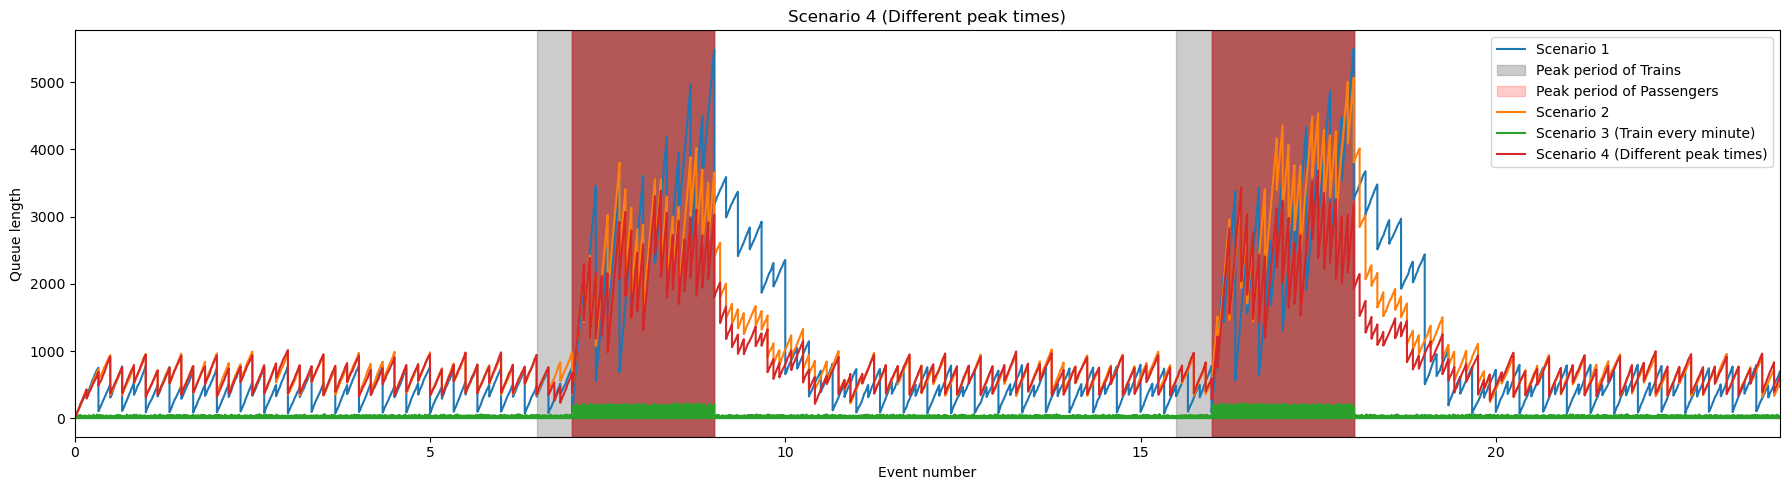

In [25]:
fig, axes = plt.subplots(figsize=(18, 5), sharey=True)
axes = [axes]

for idx, (name, scenario_stats, qh, th, peak_times) in enumerate(
    zip(
        [
            "Scenario 1",
            "Scenario 2",
            "Scenario 3 (Train every minute)",
            "Scenario 4 (Different peak times)",
        ],
        statistics,
        queue_history,
        time_history,
        [
            scenario.peak_times
            for scenario in [
                scenario_1,
                scenario_2,
                scenario_train_every_minute,
                scenario_different_peak_times,
            ]
        ],
    )
):
    print(name)
    scenario_stats = np.array(scenario_stats)
    print(f"Net profit: {np.mean(scenario_stats[0]).item():.2e} CHF")
    print(f"Mean waiting time: {np.mean(scenario_stats[1]).item():.2f}")
    print(f"Max waiting time: {np.mean(scenario_stats[2]).item():.2f}")
    print()
    axes[0].plot(np.array(th) / 60, qh, label=name)
    axes[0].set_title(name)
    axes[0].set_xlabel("Event number")
    axes[0].set_ylabel("Queue length")
    axes[0].set_xlim(0, 24)
    for idx_peaks, (peak_start, peak_end) in enumerate(peak_times):
        peak_start_hours = peak_start / 60
        peak_end_hours = peak_end / 60
        axes[0].axvspan(
            peak_start_hours,
            peak_end_hours,
            color="gray",
            alpha=0.4,
            label="Peak period of Trains" if idx == 0 and idx_peaks == 0 else None,
        )
    for idx_peaks, (peak_start, peak_end) in enumerate(PASSENGER_PEAK_TIMES):
        peak_start_hours = peak_start / 60
        peak_end_hours = peak_end / 60
        axes[0].axvspan(
            peak_start_hours,
            peak_end_hours,
            color="red",
            alpha=0.2,
            label="Peak period of Passengers" if idx == 0 and idx_peaks == 0 else None,
        )
    axes[0].legend()
plt.tight_layout()


## Simulate one scenario for many draws

We already included antithetic draws as variance reduction and calculate the bootstrapped mse (Need to fix something)

In [26]:
statistics, result = simulate(
    seed=1234,
    scenario=scenario_different_peak_times,
    min_runs=200,
    max_runs=1000,
    rng_size=100000,
    antithetic=False,
    precision_percent=1.0,
)
result

Running queue simulations...
  Run  10: Mean profit = 1390700.00, SEM = 8818.6821, error = 0.63%
  Run  20: Mean profit = 1388380.50, SEM = 5386.3755, error = 0.39%
  Run  30: Mean profit = 1386783.33, SEM = 4615.7607, error = 0.33%
  Run  40: Mean profit = 1384766.00, SEM = 4050.4899, error = 0.29%
  Run  50: Mean profit = 1385133.80, SEM = 3439.8027, error = 0.25%
  Run  60: Mean profit = 1385338.00, SEM = 3070.3890, error = 0.22%
  Run  70: Mean profit = 1385086.14, SEM = 2775.1027, error = 0.20%
  Run  80: Mean profit = 1384455.12, SEM = 2490.2085, error = 0.18%
  Run  90: Mean profit = 1384949.22, SEM = 2346.2961, error = 0.17%
  Run 100: Mean profit = 1386926.30, SEM = 2353.4081, error = 0.17%
  Run 110: Mean profit = 1386518.91, SEM = 2199.2594, error = 0.16%
  Run 120: Mean profit = 1386265.50, SEM = 2115.7971, error = 0.15%
  Run 130: Mean profit = 1385596.08, SEM = 2094.6126, error = 0.15%
  Run 140: Mean profit = 1385282.79, SEM = 2027.3191, error = 0.15%
  Run 150: Mean pro

{'net_profit': {'mean': 1385413.35,
  'sem': 1678.2696450196768,
  'bootstrap_mse': 2705932.3005416878,
  'error_percent': 0.12113855009551312,
  'q05': 1344912.0,
  'q95': 1426805.0,
  'worst': 1325170.0},
 'mean_waiting_time': {'mean': 14.054126723986165,
  'sem': 0.007972127754847094,
  'bootstrap_mse': 5.119656262918046e-05,
  'error_percent': 0.0567244618709825,
  'q05': 13.871605817971936,
  'q95': 14.24901067999305,
  'worst': 14.39069579882328},
 'max_waiting_time': {'mean': 95.63482748813632,
  'sem': 0.290625726910825,
  'bootstrap_mse': 0.0726727607471886,
  'error_percent': 0.303891097567858,
  'q05': 88.78666444073846,
  'q95': 101.61909402366292,
  'worst': 103.5786429425034},
 'p95_waiting_time': {'mean': 29.440853864875564,
  'sem': 0.0035797793852422183,
  'bootstrap_mse': 1.1624877721245791e-05,
  'error_percent': 0.012159224055363004,
  'q05': 29.363665180760197,
  'q95': 29.523141449953755,
  'worst': 29.609368615445693},
 'unserved_total': {'mean': 576.545,
  'sem'

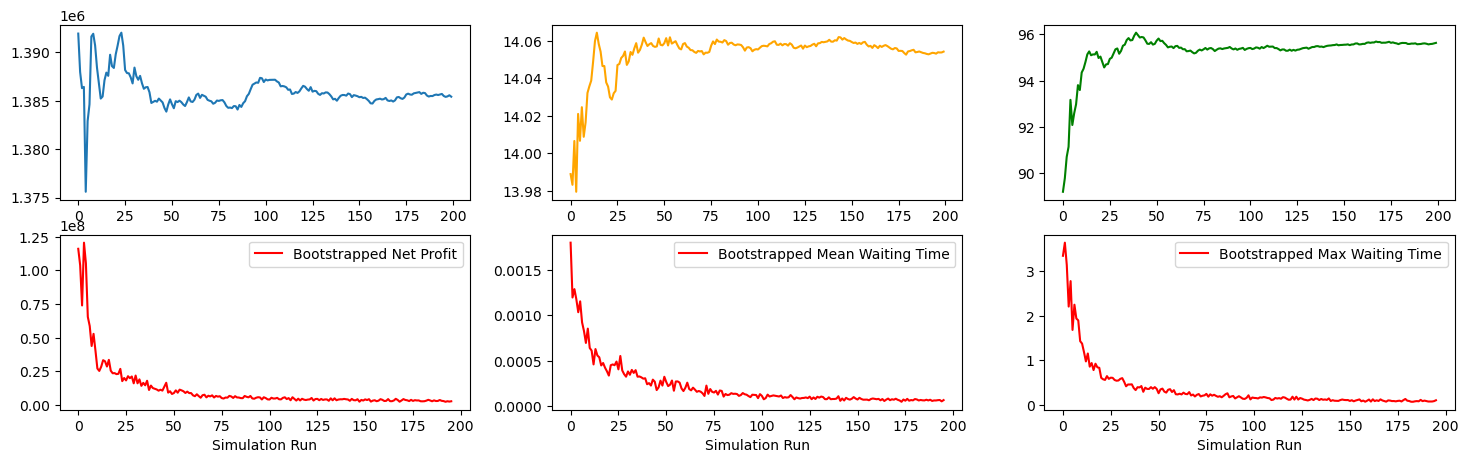

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 5))
ax1, ax2, ax3 = axes[0, 0], axes[0, 1], axes[0, 2]
ax4, ax5, ax6 = axes[1, 0], axes[1, 1], axes[1, 2]

ax1.plot(
    [np.mean(statistics[:, 0][:i]) for i in range(1, len(statistics[:, 0]) + 1)],
    label="Net Profit",
)
ax2.plot(
    [np.mean(statistics[:, 1][:i]) for i in range(1, len(statistics[:, 1]) + 1)],
    label="Mean Waiting Time",
    color="orange",
)
ax3.plot(
    [np.mean(statistics[:, 2][:i]) for i in range(1, len(statistics[:, 2]) + 1)],
    label="Max Waiting Time",
    color="green",
)

# now plot bootstrapped mean
ax4.plot(
    [
        bootstrap_function(statistics[:, 0][:i], f_statistic=np.mean, draws=100)
        for i in range(5, len(statistics[:, 0]) + 1)
    ],
    label="Bootstrapped Net Profit",
    color="red",
)
ax5.plot(
    [
        bootstrap_function(statistics[:, 1][:i], f_statistic=np.mean, draws=100)
        for i in range(5, len(statistics[:, 1]) + 1)
    ],
    label="Bootstrapped Mean Waiting Time",
    color="red",
)
ax6.plot(
    [
        bootstrap_function(statistics[:, 2][:i], f_statistic=np.mean, draws=100)
        for i in range(5, len(statistics[:, 2]) + 1)
    ],
    label="Bootstrapped Max Waiting Time",
    color="red",
)
for ax in [ax4, ax5, ax6]:
    ax.legend()
    ax.set_xlabel("Simulation Run")

## Optimization

In [28]:
# dummy optimization loop to show how it could be used
range_pre_peak = np.linspace(0, 120, 3)

scenario_params = [
    {
        "peak_frequency": 15,
        "non_peak_frequency": 30,
        "train1_first_class_carriages": 1,
        "train1_second_class_carriages": 3,
        "train2_first_class_carriages": 1,
        "train2_second_class_carriages": 3,
        "first_pre_peak_time_in_minutes": pre_preak_time,
        "second_pre_peak_time_in_minutes": pre_preak_time,
    }
    for pre_preak_time in range_pre_peak
]
scenarios = [Scenario.create(**params) for params in scenario_params]

In [29]:
result

{'net_profit': {'mean': 1385413.35,
  'sem': 1678.2696450196768,
  'bootstrap_mse': 2705932.3005416878,
  'error_percent': 0.12113855009551312,
  'q05': 1344912.0,
  'q95': 1426805.0,
  'worst': 1325170.0},
 'mean_waiting_time': {'mean': 14.054126723986165,
  'sem': 0.007972127754847094,
  'bootstrap_mse': 5.119656262918046e-05,
  'error_percent': 0.0567244618709825,
  'q05': 13.871605817971936,
  'q95': 14.24901067999305,
  'worst': 14.39069579882328},
 'max_waiting_time': {'mean': 95.63482748813632,
  'sem': 0.290625726910825,
  'bootstrap_mse': 0.0726727607471886,
  'error_percent': 0.303891097567858,
  'q05': 88.78666444073846,
  'q95': 101.61909402366292,
  'worst': 103.5786429425034},
 'p95_waiting_time': {'mean': 29.440853864875564,
  'sem': 0.0035797793852422183,
  'bootstrap_mse': 1.1624877721245791e-05,
  'error_percent': 0.012159224055363004,
  'q05': 29.363665180760197,
  'q95': 29.523141449953755,
  'worst': 29.609368615445693},
 'unserved_total': {'mean': 576.545,
  'sem'

In [30]:
optimization_params = {
    "min_runs": 50,
    "max_runs": 200,
    "rng_size": 100000,
    "precision_percent": 5.0,
    "antithetic": False,
    "verbose": False,
}
statistics_list = []
results_list = []
for idx, scenario in enumerate(scenarios):
    print(f"Step {idx + 1}/{len(scenarios)}")
    print(f"Running scenario: {scenario}")
    statistics, result = simulate(
        seed=1234 + idx,
        scenario=scenario,
        **optimization_params,
    )
    statistics_list.append(statistics)
    results_list.append(result)
    print(
        f"Net profit: {result['net_profit']['mean']:.2f} CHF, Mean waiting time: {result['mean_waiting_time']['mean']:.2f} min, Max waiting time: {result['max_waiting_time']['mean']:.2f} min"
    )
    print()


Step 1/3
Running scenario: Peak frequency: 15 min, Off-peak frequency: 30 min, Peak train: train1_peak(1F,3S), Off-peak train: train2_offpeak(1F,3S), Train peak times: ((np.float64(420.0), 540), (np.float64(960.0), 1080))
Net profit: 1330093.40 CHF, Mean waiting time: 16.43 min, Max waiting time: 112.50 min

Step 2/3
Running scenario: Peak frequency: 15 min, Off-peak frequency: 30 min, Peak train: train1_peak(1F,3S), Off-peak train: train2_offpeak(1F,3S), Train peak times: ((np.float64(360.0), 540), (np.float64(900.0), 1080))
Net profit: 1368988.80 CHF, Mean waiting time: 12.80 min, Max waiting time: 73.39 min

Step 3/3
Running scenario: Peak frequency: 15 min, Off-peak frequency: 30 min, Peak train: train1_peak(1F,3S), Off-peak train: train2_offpeak(1F,3S), Train peak times: ((np.float64(300.0), 540), (np.float64(840.0), 1080))
Net profit: 1354865.60 CHF, Mean waiting time: 10.76 min, Max waiting time: 31.47 min



In [31]:
print("Best Profit Scenario:")
best = -np.inf
for idx, result in enumerate(results_list):
    if result["net_profit"]["mean"] > best:
        best = result["net_profit"]["mean"]
        best_idx = idx
print(f"Best scenario (Scenario {best_idx + 1}):")
print(
    f"Best pre_peak_time: {scenario_params[best_idx]['first_pre_peak_time_in_minutes']} min"
)
print(f"Best result:")
print(results_list[best_idx])


Best Profit Scenario:
Best scenario (Scenario 2):
Best pre_peak_time: 60.0 min
Best result:
{'net_profit': {'mean': 1368988.8, 'sem': 2644.4900382586015, 'bootstrap_mse': 6836072.43186667, 'error_percent': 0.1931710499208322, 'q05': 1336905.0, 'q95': 1399132.5, 'worst': 1329860.0}, 'mean_waiting_time': {'mean': 12.804816035335435, 'sem': 0.013893248942307073, 'bootstrap_mse': 0.00014787832502735924, 'error_percent': 0.10850018386807012, 'q05': 12.66907982478809, 'q95': 12.945964904137194, 'worst': 13.05664040191213}, 'max_waiting_time': {'mean': 73.38689119594449, 'sem': 0.5533098172290793, 'bootstrap_mse': 0.30572377568135506, 'error_percent': 0.7539627421356914, 'q05': 68.60046104404705, 'q95': 81.28692223246694, 'worst': 84.13290475410918}, 'p95_waiting_time': {'mean': 29.301996213919583, 'sem': 0.010625832569829135, 'bootstrap_mse': 0.00011271677921526726, 'error_percent': 0.03626316955423485, 'q05': 29.210468421712946, 'q95': 29.406067138914725, 'worst': 29.506057404535625}, 'unse

### VNS:
Starting with a single objective, profit and an initial solution being scenario 1

In [32]:
def evaluate_profit(
    scenario: Scenario,
    seed: int,
    min_runs: int = 10,
    max_runs: int = 100,
    rng_size: int = 250000,
    precision_percent: float = 1.0,
    antithetic: bool = True,
    verbose: bool = False,
):
    """
    Single-objective evaluation function.

    Objective:
    maximize mean net profit.
    """
    _, summary = simulate(
        seed=seed,
        scenario=scenario,
        min_runs=min_runs,
        max_runs=max_runs,
        rng_size=rng_size,
        precision_percent=precision_percent,
        antithetic=antithetic,
        verbose=verbose,
    )

    return summary["net_profit"]["mean"], summary

In [33]:
def scenario_key(scenario: Scenario):
    """Stable key for local optimization cache."""
    return (
        scenario.train_frequency_peak,
        scenario.train_frequency_offpeak,
        scenario.train_config_1,
        scenario.train_config_2,
        scenario.train_config_3,
        scenario.train_type_2_intervals,
        scenario.train_type_3_intervals,
        scenario.peak_times,
    )


def clone_scenario(scenario: Scenario, **updates):
    data = {
        "train_frequency_peak": scenario.train_frequency_peak,
        "train_frequency_offpeak": scenario.train_frequency_offpeak,
        "train_config_1": scenario.train_config_1,
        "train_config_2": scenario.train_config_2,
        "train_config_3": scenario.train_config_3,
        "train_type_2_intervals": scenario.train_type_2_intervals,
        "train_type_3_intervals": scenario.train_type_3_intervals,
        "peak_times": scenario.peak_times,
    }

    data.update(updates)
    return Scenario(**data)


def bounded_headway(value):
    return min(MAX_HEADWAY, max(MIN_HEADWAY, value))


def valid_train_type(first, second):
    return (
        first >= 0
        and second >= 0
        and first + second > 0
        and first + second <= max_number_of_carriages
    )


def make_train_type_neighbors(train_type: TrainType):
    neighbors = []

    for delta_first, delta_second in [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1),
        (-1, 1),
        (1, -1),
    ]:
        new_first = train_type.first_class_carriages + delta_first
        new_second = train_type.second_class_carriages + delta_second

        if valid_train_type(new_first, new_second):
            if (
                new_first != train_type.first_class_carriages
                or new_second != train_type.second_class_carriages
            ):
                neighbors.append(
                    TrainType(
                        name=train_type.name,
                        first_class_carriages=new_first,
                        second_class_carriages=new_second,
                    )
                )

    return neighbors

define the neighborhood structures:
1. Change frequency peak (10 min timesteps)
2. Change frequency offpeak (10 min timesteps)
3. Train type 1: peak
    - Change number of first class carriages
    - Change number of second class carriages
4. Train type 2: offpeak
    - Change number of first class carriages
    - Change number of second class carriages
5. peak times morning 
    - start
    - end
6. peak times evening
    - start
    - end

The neighborhood structure will be the following:
1. Peaks and offpeaks variation of frequency by 5 minutes

2. Train Type 1 and 2, changing the number of first and second class carriages

3. Morning and evening peaktimes start and end

In [34]:
def neighborhood_1_peak_freq(scenario: Scenario, step: float = 5, **kwargs):
    neighbors = []
    current_freq = scenario.train_frequency_peak

    for delta in [-step, step]:
        new_freq = bounded_headway(current_freq + delta)

        if new_freq != current_freq:
            neighbors.append(
                clone_scenario(
                    scenario,
                    train_frequency_peak=new_freq,
                )
            )

    return neighbors


def neighborhood_2_offpeak_freq(scenario: Scenario, step: float = 5, **kwargs):
    neighbors = []
    current_freq = scenario.train_frequency_offpeak

    for delta in [-step, step]:
        new_freq = bounded_headway(current_freq + delta)

        if new_freq != current_freq:
            neighbors.append(
                clone_scenario(
                    scenario,
                    train_frequency_offpeak=new_freq,
                )
            )

    return neighbors


def neighborhood_3_train_type_1(scenario: Scenario, **kwargs):
    """Changes peak train composition."""
    return [
        clone_scenario(
            scenario,
            train_config_1=new_train_type_1,
        )
        for new_train_type_1 in make_train_type_neighbors(scenario.train_config_1)
    ]


def neighborhood_4_train_type_2(scenario: Scenario, **kwargs):
    """Changes off-peak train composition."""
    if scenario.train_config_2 is None:
        return []

    return [
        clone_scenario(
            scenario,
            train_config_2=new_train_type_2,
        )
        for new_train_type_2 in make_train_type_neighbors(scenario.train_config_2)
    ]


def peak_offsets_from_scenario(scenario: Scenario):
    current_morning_start, current_morning_end = scenario.peak_times[0]
    current_afternoon_start, current_afternoon_end = scenario.peak_times[1]

    return {
        "first_pre_peak_time_in_minutes": (
            PASSENGER_PEAK_TIMES[0][0] - current_morning_start
        ),
        "first_post_peak_time_in_minutes": (
            current_morning_end - PASSENGER_PEAK_TIMES[0][1]
        ),
        "second_pre_peak_time_in_minutes": (
            PASSENGER_PEAK_TIMES[1][0] - current_afternoon_start
        ),
        "second_post_peak_time_in_minutes": (
            current_afternoon_end - PASSENGER_PEAK_TIMES[1][1]
        ),
    }


def scenario_from_offsets(scenario: Scenario, offsets: dict):
    return Scenario.create(
        peak_frequency=scenario.train_frequency_peak,
        non_peak_frequency=scenario.train_frequency_offpeak,
        train1_first_class_carriages=scenario.train_config_1.first_class_carriages,
        train1_second_class_carriages=scenario.train_config_1.second_class_carriages,
        train2_first_class_carriages=(
            scenario.train_config_2.first_class_carriages
            if scenario.train_config_2 is not None
            else scenario.train_config_1.first_class_carriages
        ),
        train2_second_class_carriages=(
            scenario.train_config_2.second_class_carriages
            if scenario.train_config_2 is not None
            else scenario.train_config_1.second_class_carriages
        ),
        **offsets,
    )


def neighborhood_5_prepost_peak_times(
    scenario: Scenario,
    step: float = 5,
    max_extension: float = 180,
    **kwargs,
):
    """
    Changes the train-service peak intervals around the fixed passenger peaks.
    """
    neighbors = []
    offsets = peak_offsets_from_scenario(scenario)

    for param_name, current_value in offsets.items():
        for delta in [-step, step]:
            new_value = current_value + delta

            if new_value < 0 or new_value > max_extension:
                continue

            new_offsets = dict(offsets)
            new_offsets[param_name] = new_value

            neighbors.append(
                scenario_from_offsets(
                    scenario,
                    new_offsets,
                )
            )

    return neighbors

main VNS function

In [35]:
def variable_neighborhood_search(
    initial_scenario: Scenario,
    seed: int,
    iterations: int = 50,
    optimization_params: dict | None = None,
    verbose: bool = True,
):
    """
    Variable Neighborhood Search algorithm.

    Single-objective version:
    maximize mean net profit.
    """

    if optimization_params is None:
        optimization_params = {
            "min_runs": 20,
            "max_runs": 100,
            "rng_size": 250000,
            "precision_percent": 5.0,
            "antithetic": True,
            "verbose": False,
        }

    neighborhood_structures = {
        1: neighborhood_1_peak_freq,
        2: neighborhood_2_offpeak_freq,
        3: neighborhood_3_train_type_1,
        4: neighborhood_4_train_type_2,
        5: neighborhood_5_prepost_peak_times,
    }

    evaluation_cache = {}

    def cached_evaluate(scenario):
        key = (scenario_key(scenario), seed)

        if key not in evaluation_cache:
            evaluation_cache[key] = evaluate_profit(
                scenario=scenario,
                seed=seed,
                **optimization_params,
            )

        return evaluation_cache[key]

    current_scenario = initial_scenario
    current_profit, current_summary = cached_evaluate(current_scenario)

    best_scenario = current_scenario
    best_profit = current_profit
    best_summary = current_summary

    search_history = [
        {
            "scenario": current_scenario,
            "profit": current_profit,
            "summary": current_summary,
            "neighborhood": 0,
        }
    ]

    if verbose:
        print(f"Initial profit: {current_profit:.2f} CHF")

    neighborhood_idx = 1
    iteration = 0

    while iteration < iterations and neighborhood_idx <= len(neighborhood_structures):
        iteration += 1

        neighborhood_func = neighborhood_structures[neighborhood_idx]
        neighbors = neighborhood_func(current_scenario)

        if not neighbors:
            if verbose:
                print(
                    f"Iteration {iteration}: "
                    f"Neighborhood {neighborhood_idx} has no valid neighbors."
                )

            neighborhood_idx += 1
            continue

        best_neighbor = None
        best_neighbor_profit = current_profit
        best_neighbor_summary = None

        for neighbor in neighbors:
            neighbor_profit, neighbor_summary = cached_evaluate(neighbor)

            search_history.append(
                {
                    "scenario": neighbor,
                    "profit": neighbor_profit,
                    "summary": neighbor_summary,
                    "neighborhood": neighborhood_idx,
                }
            )

            if verbose:
                print(
                    f"Neighborhood {neighborhood_idx}: "
                    f"profit = {neighbor_profit:.2f} CHF, "
                    f"mean wait = "
                    f"{neighbor_summary['mean_waiting_time']['mean']:.2f} min, "
                    f"p95 wait = "
                    f"{neighbor_summary['p95_waiting_time']['mean']:.2f} min, "
                    f"unserved = "
                    f"{neighbor_summary['unserved_total']['mean']:.2f}"
                )

            if neighbor_profit > best_neighbor_profit:
                best_neighbor = neighbor
                best_neighbor_profit = neighbor_profit
                best_neighbor_summary = neighbor_summary

        if best_neighbor is not None:
            current_scenario = best_neighbor
            current_profit = best_neighbor_profit
            current_summary = best_neighbor_summary

            if current_profit > best_profit:
                best_scenario = current_scenario
                best_profit = current_profit
                best_summary = current_summary

            neighborhood_idx = 1

            if verbose:
                print(
                    f"Iteration {iteration}: improvement found. "
                    f"Resetting to neighborhood 1. "
                    f"Current profit: {current_profit:.2f} CHF"
                )

            continue

        if verbose:
            print(
                f"Iteration {iteration}: no improvement in neighborhood "
                f"{neighborhood_idx}. Current profit: {current_profit:.2f} CHF"
            )

        neighborhood_idx += 1

    if verbose:
        print("\nVNS complete.")
        print(f"Best profit found: {best_profit:.2f} CHF")
        print(
            f"Best mean waiting time: "
            f"{best_summary['mean_waiting_time']['mean']:.2f} min"
        )
        print(
            f"Best p95 waiting time: "
            f"{best_summary['p95_waiting_time']['mean']:.2f} min"
        )
        print(f"Best unserved passengers: {best_summary['unserved_total']['mean']:.2f}")
        print(f"Total scenarios evaluated: {len(search_history)}")

    return best_scenario, best_profit, best_summary, search_history


#### Example: Run Variable Neighborhood Search


In [36]:
initial_scenario = Scenario.create(
    peak_frequency=15,
    non_peak_frequency=30,
    train1_first_class_carriages=1,
    train1_second_class_carriages=1,
    train2_first_class_carriages=1,
    train2_second_class_carriages=1,
)

vns_optimization_params = {
    "min_runs": 20,
    "max_runs": 100,
    "rng_size": 250000,
    "precision_percent": 5.0,
    "antithetic": True,
    "verbose": False,
}

best_scenario, best_profit, best_summary, history = variable_neighborhood_search(
    initial_scenario=initial_scenario,
    seed=67,
    iterations=100,
    optimization_params=vns_optimization_params,
    verbose=True,
)

print("\nBest scenario found:")
print(best_scenario)

print("\nBest scenario summary:")
print(f"Mean profit: {best_summary['net_profit']['mean']:.2f} CHF")
print(f"Profit SEM: {best_summary['net_profit']['sem']:.2f} CHF")
print(f"Profit bootstrap MSE: {best_summary['net_profit']['bootstrap_mse']:.2f}")
print(f"Profit q05: {best_summary['net_profit']['q05']:.2f} CHF")
print(f"Profit q95: {best_summary['net_profit']['q95']:.2f} CHF")
print(f"Profit worst: {best_summary['net_profit']['worst']:.2f} CHF")

print(f"Mean waiting time: {best_summary['mean_waiting_time']['mean']:.2f} min")
print(f"P95 waiting time: {best_summary['p95_waiting_time']['mean']:.2f} min")
print(f"Max waiting time: {best_summary['max_waiting_time']['mean']:.2f} min")
print(f"Unserved passengers: {best_summary['unserved_total']['mean']:.2f}")

Initial profit: -5214071.50 CHF
Neighborhood 1: profit = -4078816.50 CHF, mean wait = 98.17 min, p95 wait = 451.18 min, unserved = 17118.10
Neighborhood 1: profit = -5743418.50 CHF, mean wait = 157.67 min, p95 wait = 432.10 min, unserved = 28425.75
Iteration 1: improvement found. Resetting to neighborhood 1. Current profit: -4078816.50 CHF
Neighborhood 1: profit = -717528.50 CHF, mean wait = 40.01 min, p95 wait = 157.60 min, unserved = 3918.50
Neighborhood 1: profit = -5214071.50 CHF, mean wait = 136.37 min, p95 wait = 439.83 min, unserved = 24561.95
Iteration 2: improvement found. Resetting to neighborhood 1. Current profit: -717528.50 CHF
Neighborhood 1: profit = -5221625.00 CHF, mean wait = 22.68 min, p95 wait = 96.60 min, unserved = 2103.45
Neighborhood 1: profit = -4078816.50 CHF, mean wait = 98.17 min, p95 wait = 451.18 min, unserved = 17118.10
Iteration 3: no improvement in neighborhood 1. Current profit: -717528.50 CHF
Neighborhood 2: profit = 386187.86 CHF, mean wait = 24.92 m

Best scenario found:
  Peak frequency: 5 min
  Off-peak frequency: 20 min
  Train Type 1: 1 first class, 1 second class

 Best peaktimes: ((420, 540), (960, 1080))

Best profit: 839319.50 CHF
Total scenarios evaluated: 33


,evaluated_scenario,neighborhood,profit,best_so_far
0,0,0,-5.214072e+06,-5.214072e+06
1,1,1,-4.078816e+06,-4.078816e+06
2,2,1,-5.743418e+06,-4.078816e+06
3,3,1,-7.175285e+05,-7.175285e+05
4,4,1,-5.214072e+06,-7.175285e+05
5,5,1,-5.221625e+06,-7.175285e+05
6,6,1,-4.078816e+06,-7.175285e+05
7,7,2,3.861879e+05,3.861879e+05
8,8,2,-2.894778e+06,3.861879e+05
9,9,1,-4.566608e+06,3.861879e+05


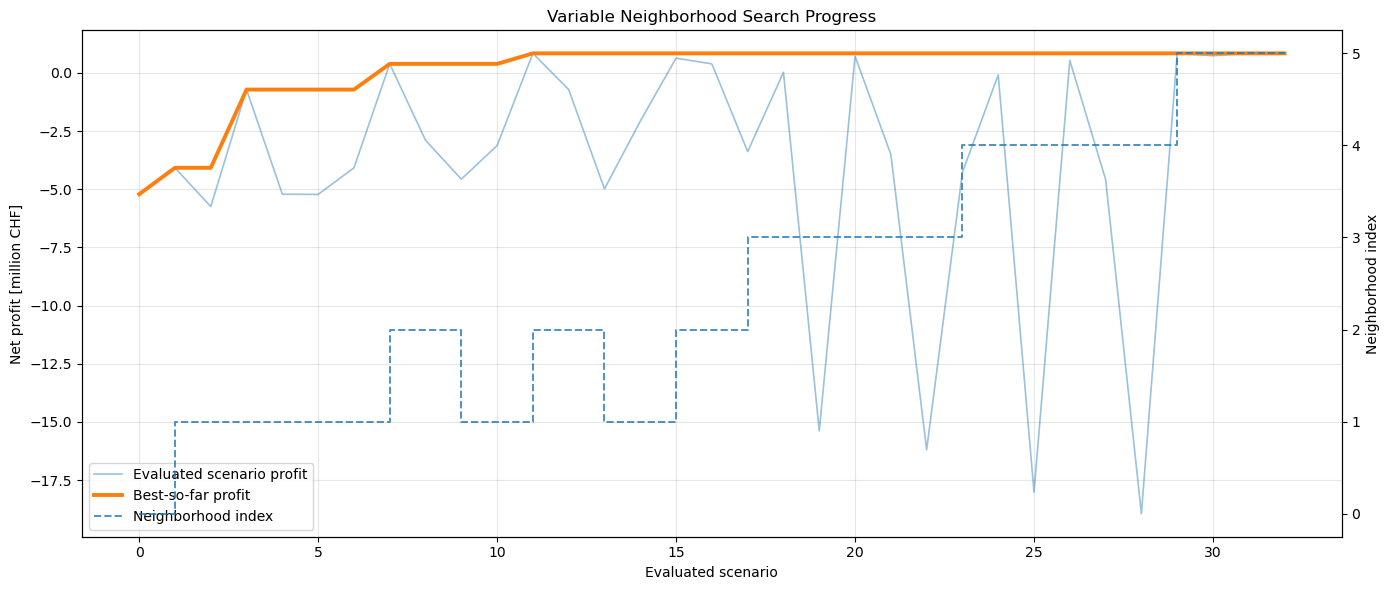

In [40]:
# Analyze VNS results
print(f"Best scenario found:")
print(f"  Peak frequency: {best_scenario.train_frequency_peak} min")
print(f"  Off-peak frequency: {best_scenario.train_frequency_offpeak} min")
print(f"  Train Type 1: {best_scenario.train_config_1.first_class_carriages} first class, "
      f"{best_scenario.train_config_1.second_class_carriages} second class")
print(f"\n Best peaktimes: {best_scenario.peak_times}")
print(f"\nBest profit: {best_profit:.2f} CHF")
print(f"Total scenarios evaluated: {len(history)}")

# Plot the search history
import matplotlib.pyplot as plt


profits = np.array([entry["profit"] for entry in history], dtype=float)
neighborhoods = np.array([entry["neighborhood"] for entry in history], dtype=int)

best_so_far = np.maximum.accumulate(profits)

fig, ax1 = plt.subplots(figsize=(14, 6))

# All evaluated candidate scenarios
ax1.plot(
    profits / 1e6,
    linewidth=1.2,
    alpha=0.45,
    label="Evaluated scenario profit",
)

# Best solution found so far
ax1.plot(
    best_so_far / 1e6,
    linewidth=2.8,
    label="Best-so-far profit",
)

ax1.set_ylabel("Net profit [million CHF]")
ax1.set_xlabel("Evaluated scenario")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.step(
    range(len(neighborhoods)),
    neighborhoods,
    where="post",
    linestyle="--",
    linewidth=1.4,
    alpha=0.8,
    label="Neighborhood index",
)

ax2.set_ylabel("Neighborhood index")
ax2.set_yticks(sorted(set(neighborhoods)))

ax1.set_title("Variable Neighborhood Search Progress")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.tight_layout()

progress_df = pd.DataFrame(
    {
        "evaluated_scenario": np.arange(len(history)),
        "neighborhood": neighborhoods,
        "profit": profits,
        "best_so_far": best_so_far,
    }
)

progress_df

In [38]:
print(history)

[{'scenario': Scenario(train_frequency_peak=15, train_frequency_offpeak=30, train_config_1=train1_peak(1F,1S), train_config_2=train2_offpeak(1F,1S), train_config_3=None, train_type_2_intervals=None, train_type_3_intervals=None, peak_times=((420, 540), (960, 1080))), 'profit': -5214071.5, 'summary': {'net_profit': {'mean': -5214071.5, 'sem': 24491.307429747823, 'bootstrap_mse': 579512529.9558333, 'error_percent': 0.46971560381839456, 'q05': -5389080.5, 'q95': -5073241.0, 'worst': -5447420.0}, 'mean_waiting_time': {'mean': 136.37424803141863, 'sem': 0.25251407811140253, 'bootstrap_mse': 0.05738016495649736, 'error_percent': 0.1851625814671601, 'q05': 133.87419552171528, 'q95': 137.8501109700892, 'worst': 138.02611940842368}, 'max_waiting_time': {'mean': 906.82502390579, 'sem': 0.7330427301874819, 'bootstrap_mse': 0.5784939602900372, 'error_percent': 0.08083618237950585, 'q05': 901.4609394362586, 'q95': 911.5982036734687, 'worst': 912.3633760541084}, 'p95_waiting_time': {'mean': 439.82986

Scenario 4 (Different peak times)
Net profit: 1.38e+06 CHF
Mean waiting time: 14.02
Max waiting time: 96.52



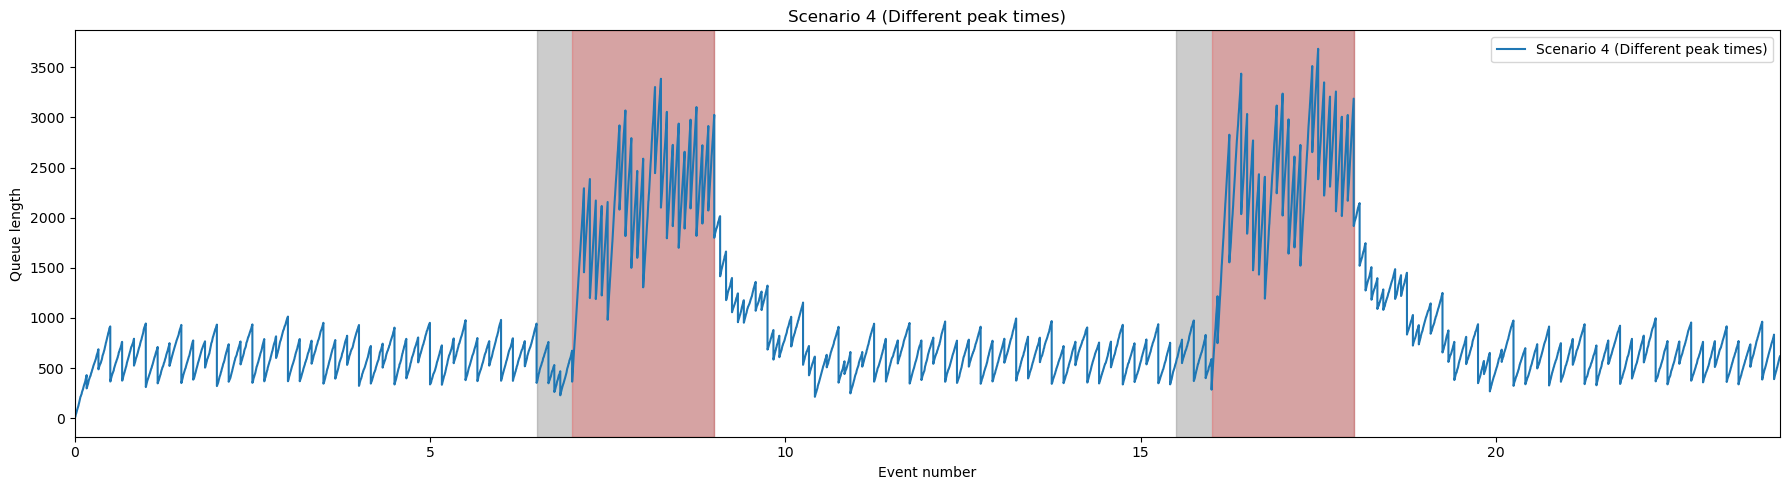

In [39]:
fig, axes = plt.subplots(figsize=(18, 5), sharey=True)
axes = [axes]

print(name)
scenario_stats = np.array(scenario_stats)
print(f"Net profit: {np.mean(scenario_stats[0]).item():.2e} CHF")
print(f"Mean waiting time: {np.mean(scenario_stats[1]).item():.2f}")
print(f"Max waiting time: {np.mean(scenario_stats[2]).item():.2f}")
print()
axes[0].plot(np.array(th) / 60, qh, label=name)
axes[0].set_title(name)
axes[0].set_xlabel("Event number")
axes[0].set_ylabel("Queue length")
axes[0].set_xlim(0, 24)
for idx_peaks, (peak_start, peak_end) in enumerate(peak_times):
    peak_start_hours = peak_start / 60
    peak_end_hours = peak_end / 60
    axes[0].axvspan(
        peak_start_hours,
        peak_end_hours,
        color="gray",
        alpha=0.4,
        label="Peak period of Trains" if idx == 0 and idx_peaks == 0 else None,
    )
for idx_peaks, (peak_start, peak_end) in enumerate(PASSENGER_PEAK_TIMES):
    peak_start_hours = peak_start / 60
    peak_end_hours = peak_end / 60
    axes[0].axvspan(
        peak_start_hours,
        peak_end_hours,
        color="red",
        alpha=0.2,
        label="Peak period of Passengers" if idx == 0 and idx_peaks == 0 else None,
    )
axes[0].legend()
plt.tight_layout()


In [ ]:
# Multi-objective optimization


OBJECTIVE_NAMES = [
    "-mean_net_profit",
    "mean_waiting_time",
    "p95_waiting_time",
]


def train_objective_vector(summary: dict):
    """
    Multi-objective cost vector to minimize.

    Objectives:
    1. Minimize -mean_net_profit 
    2. Minimize mean_waiting_time
    3. Minimize p95_waiting_time
    """
    cost = np.array(
        [
            -summary["net_profit"]["mean"],
            summary["mean_waiting_time"]["mean"],
            summary["p95_waiting_time"]["mean"],
        ],
        dtype=float,
    )

    return np.nan_to_num(cost, nan=1e18, posinf=1e18, neginf=-1e18)


def mo_dominance(cost_x1, cost_x2, atol=1e-9):
    """
    Returns True if cost_x1 dominates cost_x2.

    Since all objectives are written as minimization objectives,
    x1 dominates x2 if:
    - x1 is no worse than x2 in all objectives;
    - x1 is strictly better than x2 in at least one objective.
    """
    cost_x1 = np.asarray(cost_x1, dtype=float)
    cost_x2 = np.asarray(cost_x2, dtype=float)

    no_worse_all = np.all(cost_x1 <= cost_x2 + atol)
    strictly_better_one = np.any(cost_x1 < cost_x2 - atol)

    return no_worse_all and strictly_better_one


def same_objective_vector(cost_x1, cost_x2, atol=1e-9):
    """Checks whether two objective vectors are numerically equivalent."""
    return np.allclose(cost_x1, cost_x2, atol=atol, rtol=0.0)


def evaluate_train_multiobjective(
    scenario: Scenario,
    seed: int,
    optimization_params: dict,
    cache: dict | None = None,
):
    """
    Evaluates one train-service scenario for multi-objective optimization.

    Returns:
    - summary: simulation summary dictionary;
    - cost_vector: multi-objective vector in minimization form.
    """
    key = (scenario_key(scenario), seed)

    if cache is not None and key in cache:
        return cache[key]

    _, summary = simulate(
        seed=seed,
        scenario=scenario,
        **optimization_params,
    )

    cost_vector = train_objective_vector(summary)

    if cache is not None:
        cache[key] = (summary, cost_vector)

    return summary, cost_vector


def generate_D_and_S_train(P: dict, cost_new: np.ndarray):
    """
    Generates the sets D and S for a new candidate solution.

    D:
        Existing Pareto solutions dominated by the new candidate.

    S:
        Existing Pareto solutions that dominate the new candidate.
        Equivalent objective vectors are also placed in S to avoid duplicates.
    """
    D = {}
    S = {}

    for key, entry in P.items():
        cost_existing = entry["cost"]

        if mo_dominance(cost_new, cost_existing):
            D[key] = entry

        if mo_dominance(cost_existing, cost_new) or same_objective_vector(
            cost_existing,
            cost_new,
        ):
            S[key] = entry

    return D, S


def update_pareto_set_train(
    P: dict,
    scenario: Scenario,
    summary: dict,
    cost_vector: np.ndarray,
    candidate_key: str,
):
    """
    Updates the Pareto set P with a new candidate scenario.

    If the candidate is dominated by at least one current Pareto solution,
    it is rejected.

    If it is not dominated, it is added to P and all solutions dominated
    by the candidate are removed.
    """
    D, S = generate_D_and_S_train(P, cost_vector)

    if S:
        return P, D, S, False

    P_updated = {
        key: entry
        for key, entry in P.items()
        if key not in D
    }

    P_updated[candidate_key] = {
        "scenario": scenario,
        "summary": summary,
        "cost": cost_vector,
    }

    return P_updated, D, S, True


def generate_train_neighbors(scenario: Scenario):
    """
    Generates all unique neighbors using the same neighborhood structures
    already used in the single-objective VNS.
    """
    neighborhood_functions = [
        neighborhood_1_peak_freq,
        neighborhood_2_offpeak_freq,
        neighborhood_3_train_type_1,
        neighborhood_4_train_type_2,
        neighborhood_5_prepost_peak_times,
    ]

    unique_neighbors = {}

    for neighborhood_func in neighborhood_functions:
        for neighbor in neighborhood_func(scenario):
            unique_neighbors[scenario_key(neighbor)] = neighbor

    return list(unique_neighbors.values())

In [42]:
def multiobjective_local_search_train(
    initial_scenarios: list[Scenario],
    seed: int,
    iterations: int = 100,
    optimization_params: dict | None = None,
    neighbors_per_iteration: int | None = 3,
    verbose: bool = True,
):
    """
    Multi-objective local search for the train-service optimization problem.

    Maintains a Pareto set P of non-dominated solutions.

    Objectives:
    - maximize mean net profit;
    - minimize mean waiting time;
    - minimize p95 waiting time.

    unserved_total is intentionally excluded from the objective vector because
    it is affected by the 24h terminal-window effect. It is kept only as a
    diagnostic output.
    """
    if optimization_params is None:
        optimization_params = {
            "min_runs": 20,
            "max_runs": 100,
            "rng_size": 250000,
            "precision_percent": 5.0,
            "antithetic": True,
            "verbose": False,
        }

    rng = np.random.default_rng(seed)

    P = {}
    D_all = {}
    R_all = {}
    history = []
    evaluation_cache = {}

    # Initialization.
    for idx, scenario in enumerate(initial_scenarios):
        summary, cost_vector = evaluate_train_multiobjective(
            scenario=scenario,
            seed=seed,
            optimization_params=optimization_params,
            cache=evaluation_cache,
        )

        candidate_key = f"init_{idx}"

        P, D, S, accepted = update_pareto_set_train(
            P=P,
            scenario=scenario,
            summary=summary,
            cost_vector=cost_vector,
            candidate_key=candidate_key,
        )

        if accepted:
            D_all.update(D)
        else:
            R_all[candidate_key] = {
                "scenario": scenario,
                "summary": summary,
                "cost": cost_vector,
            }

        history.append(
            {
                "key": candidate_key,
                "scenario": scenario,
                "summary": summary,
                "cost": cost_vector,
                "accepted": accepted,
                "source": "initialization",
                "pareto_size": len(P),
            }
        )

    if verbose:
        print(f"Initial Pareto set size: {len(P)}")

    # Main local search loop.
    for iteration in range(iterations):
        if not P:
            break

        pareto_keys = list(P.keys())
        selected_key = rng.choice(pareto_keys)
        base_scenario = P[selected_key]["scenario"]

        neighbors = generate_train_neighbors(base_scenario)

        if not neighbors:
            if verbose:
                print(f"Iteration {iteration + 1}: no neighbors generated.")
            continue

        if neighbors_per_iteration is None or neighbors_per_iteration >= len(neighbors):
            candidate_neighbors = neighbors
        else:
            selected_indices = rng.choice(
                len(neighbors),
                size=neighbors_per_iteration,
                replace=False,
            )
            candidate_neighbors = [neighbors[i] for i in selected_indices]

        for local_idx, neighbor in enumerate(candidate_neighbors):
            candidate_key = f"it_{iteration + 1}_{local_idx}"

            summary, cost_vector = evaluate_train_multiobjective(
                scenario=neighbor,
                seed=seed,
                optimization_params=optimization_params,
                cache=evaluation_cache,
            )

            P_new, D, S, accepted = update_pareto_set_train(
                P=P,
                scenario=neighbor,
                summary=summary,
                cost_vector=cost_vector,
                candidate_key=candidate_key,
            )

            if accepted:
                D_all.update(D)
                P = P_new
            else:
                R_all[candidate_key] = {
                    "scenario": neighbor,
                    "summary": summary,
                    "cost": cost_vector,
                }

            history.append(
                {
                    "key": candidate_key,
                    "scenario": neighbor,
                    "summary": summary,
                    "cost": cost_vector,
                    "accepted": accepted,
                    "source": f"neighbor_of_{selected_key}",
                    "pareto_size": len(P),
                }
            )

        if verbose and (iteration + 1) % 10 == 0:
            print(
                f"Iteration {iteration + 1}/{iterations}: "
                f"Pareto set size = {len(P)}, "
                f"evaluated solutions = {len(history)}"
            )

    if verbose:
        print("\nMulti-objective local search complete.")
        print(f"Final Pareto set size: {len(P)}")
        print(f"Total evaluated solutions: {len(history)}")
        print(f"Dominated solutions removed from Pareto set: {len(D_all)}")
        print(f"Rejected/dominated candidate solutions: {len(R_all)}")

    return P, D_all, R_all, history

In [2]:
mo_initial_scenarios = [
    scenario_1,
    scenario_2,
]

# Add the best single-objective solution if it exists.
try:
    mo_initial_scenarios.append(best_scenario)
except NameError:
    pass


mo_optimization_params = {
    "min_runs": 20,
    "max_runs": 100,
    "rng_size": 250000,
    "precision_percent": 5.0,
    "antithetic": True,
    "verbose": False,
}


P_mo, D_all_mo, R_all_mo, mo_history = multiobjective_local_search_train(
    initial_scenarios=mo_initial_scenarios,
    seed=123,
    iterations=100,
    optimization_params=mo_optimization_params,
    neighbors_per_iteration=3,
    verbose=True,
)


def pareto_set_to_dataframe(P: dict):
    rows = []

    for key, entry in P.items():
        scenario = entry["scenario"]
        summary = entry["summary"]
        cost = entry["cost"]

        peak_train = scenario.train_config_1
        offpeak_train = (
            scenario.train_config_2
            if scenario.train_config_2 is not None
            else scenario.train_config_1
        )

        rows.append(
            {
                "key": key,
                "peak_frequency": scenario.train_frequency_peak,
                "offpeak_frequency": scenario.train_frequency_offpeak,
                "peak_first_carriages": peak_train.first_class_carriages,
                "peak_second_carriages": peak_train.second_class_carriages,
                "offpeak_first_carriages": offpeak_train.first_class_carriages,
                "offpeak_second_carriages": offpeak_train.second_class_carriages,
                "morning_train_peak_start": scenario.peak_times[0][0],
                "morning_train_peak_end": scenario.peak_times[0][1],
                "evening_train_peak_start": scenario.peak_times[1][0],
                "evening_train_peak_end": scenario.peak_times[1][1],
                "mean_net_profit": summary["net_profit"]["mean"],
                "profit_q05": summary["net_profit"]["q05"],
                "profit_q95": summary["net_profit"]["q95"],
                "profit_worst": summary["net_profit"]["worst"],
                "mean_waiting_time": summary["mean_waiting_time"]["mean"],
                "p95_waiting_time": summary["p95_waiting_time"]["mean"],
                "max_waiting_time": summary["max_waiting_time"]["mean"],
                "unserved_total_diagnostic": summary["unserved_total"]["mean"],
                "objective_vector": cost,
            }
        )

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df.sort_values(
            by=[
                "mean_net_profit",
                "p95_waiting_time",
                "mean_waiting_time",
            ],
            ascending=[False, True, True],
        ).reset_index(drop=True)

    return df


def rejected_set_to_dataframe(R_all: dict):
    rows = []

    for key, entry in R_all.items():
        scenario = entry["scenario"]
        summary = entry["summary"]

        rows.append(
            {
                "key": key,
                "peak_frequency": scenario.train_frequency_peak,
                "offpeak_frequency": scenario.train_frequency_offpeak,
                "mean_net_profit": summary["net_profit"]["mean"],
                "mean_waiting_time": summary["mean_waiting_time"]["mean"],
                "p95_waiting_time": summary["p95_waiting_time"]["mean"],
                "max_waiting_time": summary["max_waiting_time"]["mean"],
                "unserved_total_diagnostic": summary["unserved_total"]["mean"],
            }
        )

    return pd.DataFrame(rows)


pareto_df = pareto_set_to_dataframe(P_mo)
rejected_df = rejected_set_to_dataframe(R_all_mo)

pareto_df

NameError: name 'scenario_1' is not defined

In [1]:
def plot_pareto_profit_vs_p95(P: dict, R_all: dict):
    pareto_df = pareto_set_to_dataframe(P)
    rejected_df = rejected_set_to_dataframe(R_all)

    fig, ax = plt.subplots(figsize=(10, 6))

    if not rejected_df.empty:
        ax.scatter(
            rejected_df["p95_waiting_time"],
            rejected_df["mean_net_profit"] / 1e6,
            alpha=0.35,
            marker="x",
            label="Rejected / dominated candidates",
        )

    if not pareto_df.empty:
        ax.scatter(
            pareto_df["p95_waiting_time"],
            pareto_df["mean_net_profit"] / 1e6,
            s=80,
            label="Non-dominated Pareto set",
        )

        for _, row in pareto_df.iterrows():
            ax.annotate(
                row["key"],
                (
                    row["p95_waiting_time"],
                    row["mean_net_profit"] / 1e6,
                ),
                fontsize=8,
                xytext=(4, 4),
                textcoords="offset points",
            )

    ax.set_xlabel("P95 waiting time [min] — minimize")
    ax.set_ylabel("Mean net profit [million CHF] — maximize")
    ax.set_title("Pareto frontier: Profit vs P95 waiting time")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()


def plot_pareto_profit_vs_mean_wait(P: dict, R_all: dict):
    pareto_df = pareto_set_to_dataframe(P)
    rejected_df = rejected_set_to_dataframe(R_all)

    fig, ax = plt.subplots(figsize=(10, 6))

    if not rejected_df.empty:
        ax.scatter(
            rejected_df["mean_waiting_time"],
            rejected_df["mean_net_profit"] / 1e6,
            alpha=0.35,
            marker="x",
            label="Rejected / dominated candidates",
        )

    if not pareto_df.empty:
        ax.scatter(
            pareto_df["mean_waiting_time"],
            pareto_df["mean_net_profit"] / 1e6,
            s=80,
            label="Non-dominated Pareto set",
        )

        for _, row in pareto_df.iterrows():
            ax.annotate(
                row["key"],
                (
                    row["mean_waiting_time"],
                    row["mean_net_profit"] / 1e6,
                ),
                fontsize=8,
                xytext=(4, 4),
                textcoords="offset points",
            )

    ax.set_xlabel("Mean waiting time [min] — minimize")
    ax.set_ylabel("Mean net profit [million CHF] — maximize")
    ax.set_title("Pareto frontier: Profit vs Mean waiting time")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()


def plot_pareto_set_size(mo_history: list):
    mo_pareto_sizes = np.array(
        [entry["pareto_size"] for entry in mo_history],
        dtype=int,
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        mo_pareto_sizes,
        linewidth=2,
    )

    ax.set_xlabel("Evaluated candidate")
    ax.set_ylabel("Pareto set size")
    ax.set_title("Evolution of Pareto set size")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()


plot_pareto_profit_vs_p95(P_mo, R_all_mo)
plot_pareto_profit_vs_mean_wait(P_mo, R_all_mo)
plot_pareto_set_size(mo_history)


print("Final Pareto solutions:")

for idx, row in pareto_df.iterrows():
    print("\n" + "-" * 80)
    print(f"Pareto solution {idx + 1}: {row['key']}")
    print(
        f"Frequency: peak {row['peak_frequency']} min, "
        f"off-peak {row['offpeak_frequency']} min"
    )
    print(
        f"Peak train: {row['peak_first_carriages']}F + "
        f"{row['peak_second_carriages']}S"
    )
    print(
        f"Off-peak train: {row['offpeak_first_carriages']}F + "
        f"{row['offpeak_second_carriages']}S"
    )
    print(
        f"Train peak times: "
        f"morning ({row['morning_train_peak_start']}, "
        f"{row['morning_train_peak_end']}), "
        f"evening ({row['evening_train_peak_start']}, "
        f"{row['evening_train_peak_end']})"
    )
    print(f"Mean net profit: {row['mean_net_profit']:.2f} CHF")
    print(f"Profit q05: {row['profit_q05']:.2f} CHF")
    print(f"Profit q95: {row['profit_q95']:.2f} CHF")
    print(f"Profit worst: {row['profit_worst']:.2f} CHF")
    print(f"Mean waiting time: {row['mean_waiting_time']:.2f} min")
    print(f"P95 waiting time: {row['p95_waiting_time']:.2f} min")
    print(f"Max waiting time: {row['max_waiting_time']:.2f} min")
    print(
        f"Unserved passengers diagnostic only: "
        f"{row['unserved_total_diagnostic']:.2f}"
    )

NameError: name 'P_mo' is not defined